###### A few years ago, the Tanzanian Ministry of Water conducted a survey of tens of thousands of water pumps
that had been installed around the country over the years. The Ministry knew what kind of pumps existed, 
which organizations had installed them, and how they were managed. The survey added one last important detail to the existing knowledge: did the pumps still work?

The Ministry's data about the pumps and their status was collected into a dataset and organized into a competition
by DrivenData, a platform that organizes data science
competitions around problems with humanitarian impact.
Predictive analytics on this dataset could allow the Ministry to know in advance which pumps are most likely to
be non-functional, so that they can triage their repair efforts. It's hard to find much simpler 
examples of how a good predictive
model can directly save time and money.

##### Import Libraries

In [3]:
import pandas as pd
pd.set_option('display.max_columns', None)
#import pandas_profiling
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from datasist.structdata import detect_outliers 
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay


In [42]:
df1=pd.read_csv('train-labels.csv')

In [43]:
df1

,id,status_group
0,69572,functional
1,8776,functional
2,34310,functional
3,67743,non functional
4,19728,functional
...,...,...
59395,60739,functional
59396,27263,functional
59397,37057,functional
59398,31282,functional


In [44]:
df2=pd.read_csv('train.csv')

In [45]:
df2.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,0,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe


#### Merge with  df1 and df2

In [46]:
df = pd.merge(df2, df1, on='id')


In [47]:
df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,0,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 55765 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59400 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59029 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lg

In [49]:
df.duplicated().sum()

0

In [50]:
df.shape

(59400, 41)

In [51]:
for col in df.columns:
    print(col,'___________>>>>' ,len(df[col].unique()))


id ___________>>>> 59400
amount_tsh ___________>>>> 98
date_recorded ___________>>>> 356
funder ___________>>>> 1898
gps_height ___________>>>> 2428
installer ___________>>>> 2146
longitude ___________>>>> 57516
latitude ___________>>>> 57517
wpt_name ___________>>>> 37400
num_private ___________>>>> 65
basin ___________>>>> 9
subvillage ___________>>>> 19288
region ___________>>>> 21
region_code ___________>>>> 27
district_code ___________>>>> 20
lga ___________>>>> 125
ward ___________>>>> 2092
population ___________>>>> 1049
public_meeting ___________>>>> 3
recorded_by ___________>>>> 1
scheme_management ___________>>>> 13
scheme_name ___________>>>> 2697
permit ___________>>>> 3
construction_year ___________>>>> 55
extraction_type ___________>>>> 18
extraction_type_group ___________>>>> 13
extraction_type_class ___________>>>> 7
management ___________>>>> 12
management_group ___________>>>> 5
payment ___________>>>> 7
payment_type ___________>>>> 7
water_quality ___________>>>> 8
q

In [52]:
df['recorded_by'].value_counts()

GeoData Consultants Ltd    59400
Name: recorded_by, dtype: int64

In [53]:
df['installer'].value_counts().head(10)

DWE                   17402
Government             1825
RWE                    1206
Commu                  1060
DANIDA                 1050
KKKT                    898
Hesawa                  840
0                       777
TCRS                    707
Central government      622
Name: installer, dtype: int64

In [54]:
df['funder'].value_counts().head(10)

Government Of Tanzania    9084
Danida                    3114
Hesawa                    2202
Rwssp                     1374
World Bank                1349
Kkkt                      1287
World Vision              1246
Unicef                    1057
Tasaf                      877
District Council           843
Name: funder, dtype: int64

In [55]:
df['lga'].value_counts()

Njombe          2503
Arusha Rural    1252
Moshi Rural     1251
Bariadi         1177
Rungwe          1106
                ... 
Moshi Urban       79
Kigoma Urban      71
Arusha Urban      63
Lindi Urban       21
Nyamagana          1
Name: lga, Length: 125, dtype: int64

###### Drop unnicessary columns


In [56]:
df.drop(['id','wpt_name','scheme_name','subvillage','funder','installer','recorded_by','quantity_group','lga', 'ward','source_type','waterpoint_type_group','quantity_group','extraction_type_group'],axis=1,inplace=True)

In [24]:
df.isnull().mean()*100

amount_tsh               0.000000
date_recorded            0.000000
gps_height               0.000000
longitude                0.000000
latitude                 0.000000
num_private              0.000000
basin                    0.000000
region                   0.000000
region_code              0.000000
district_code            0.000000
population               0.000000
public_meeting           5.612795
scheme_management        6.526936
permit                   5.144781
construction_year        0.000000
extraction_type          0.000000
extraction_type_class    0.000000
management               0.000000
management_group         0.000000
payment                  0.000000
payment_type             0.000000
water_quality            0.000000
quality_group            0.000000
quantity                 0.000000
source                   0.000000
source_class             0.000000
waterpoint_type          0.000000
status_group             0.000000
dtype: float64

In [25]:
df_null_values=df.columns[df.isnull().any()].tolist()

In [26]:
df_null_values

['public_meeting', 'scheme_management', 'permit']

In [27]:
df

,amount_tsh,date_recorded,gps_height,longitude,latitude,num_private,basin,region,region_code,district_code,population,public_meeting,scheme_management,permit,construction_year,extraction_type,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,source,source_class,waterpoint_type,status_group
0,6000.0,2011-03-14,1390,34.938093,-9.856322,0,Lake Nyasa,Iringa,11,5,109,True,VWC,False,1999,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,spring,groundwater,communal standpipe,functional
1,0.0,2013-03-06,1399,34.698766,-2.147466,0,Lake Victoria,Mara,20,2,280,NaN,Other,True,2010,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,rainwater harvesting,surface,communal standpipe,functional
2,25.0,2013-02-25,686,37.460664,-3.821329,0,Pangani,Manyara,21,4,250,True,VWC,True,2009,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,dam,surface,communal standpipe multiple,functional
3,0.0,2013-01-28,263,38.486161,-11.155298,0,Ruvuma / Southern Coast,Mtwara,90,63,58,True,VWC,True,1986,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,machine dbh,groundwater,communal standpipe multiple,non functional
4,0.0,2011-07-13,0,31.130847,-1.825359,0,Lake Victoria,Kagera,18,1,0,True,NaN,True,0,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,rainwater harvesting,surface,communal standpipe,functional
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59395,10.0,2013-05-03,1210,37.169807,-3.253847,0,Pangani,Kilimanjaro,3,5,125,True,Water Board,True,1999,gravity,gravity,water board,user-group,pay per bucket,per bucket,soft,good,enough,spring,groundwater,communal standpipe,functional
59396,4700.0,2011-05-07,1212,35.249991,-9.070629,0,Rufiji,Iringa,11,4,56,True,VWC,True,1996,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,river,surface,communal standpipe,functional
59397,0.0,2011-04-11,0,34.017087,-8.750434,0,Rufiji,Mbeya,12,7,0,True,VWC,False,0,swn 80,handpump,vwc,user-group,pay monthly,monthly,fluoride,fluoride,enough,machine dbh,groundwater,hand pump,functional
59398,0.0,2011-03-08,0,35.861315,-6.378573,0,Rufiji,Dodoma,1,4,0,True,VWC,True,0,nira/tanira,handpump,vwc,user-group,never pay,never pay,soft,good,insufficient,shallow well,groundwater,hand pump,functional


In [28]:

data_loc=df.loc[(df['longitude']>0)& (df['latitude']<0)]

<Axes: xlabel='longitude', ylabel='latitude'>

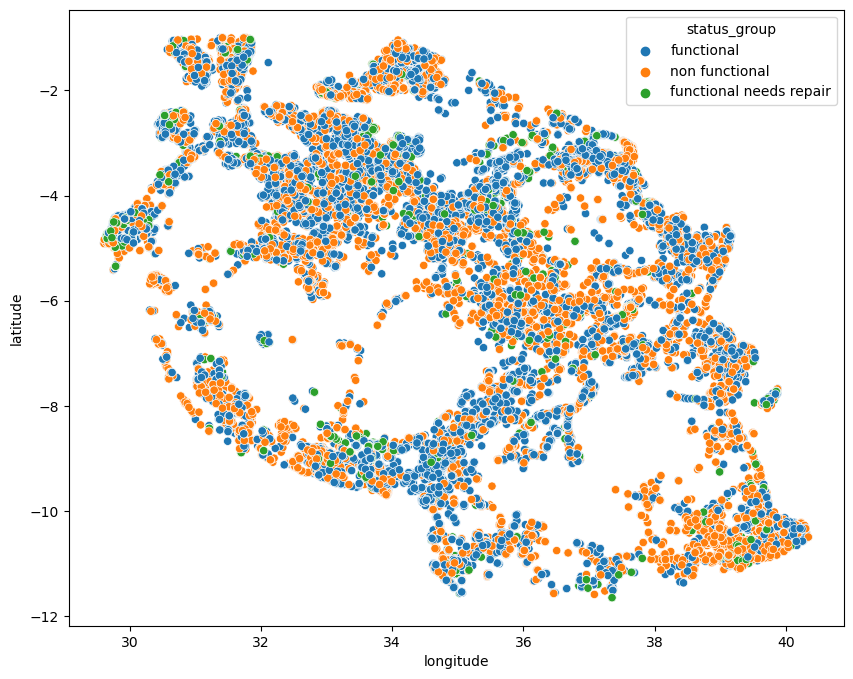

In [29]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.scatterplot(data=data_loc,x='longitude',y='latitude',hue='status_group',ax=ax)

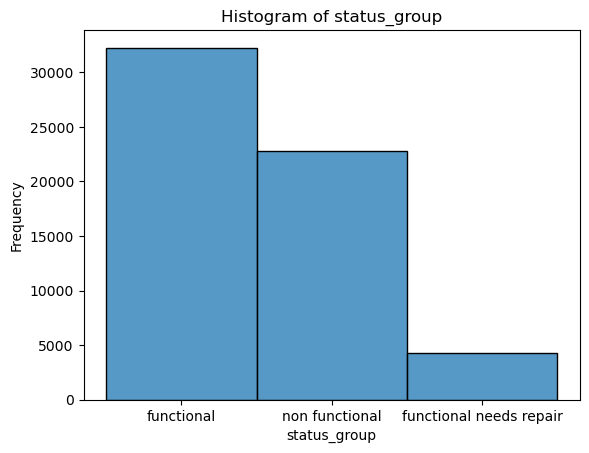

In [310]:
    sns.histplot(df['status_group'])  
    plt.title(f'Histogram of {"status_group"}')
    plt.xlabel('status_group')
    plt.ylabel('Frequency')
    plt.show()

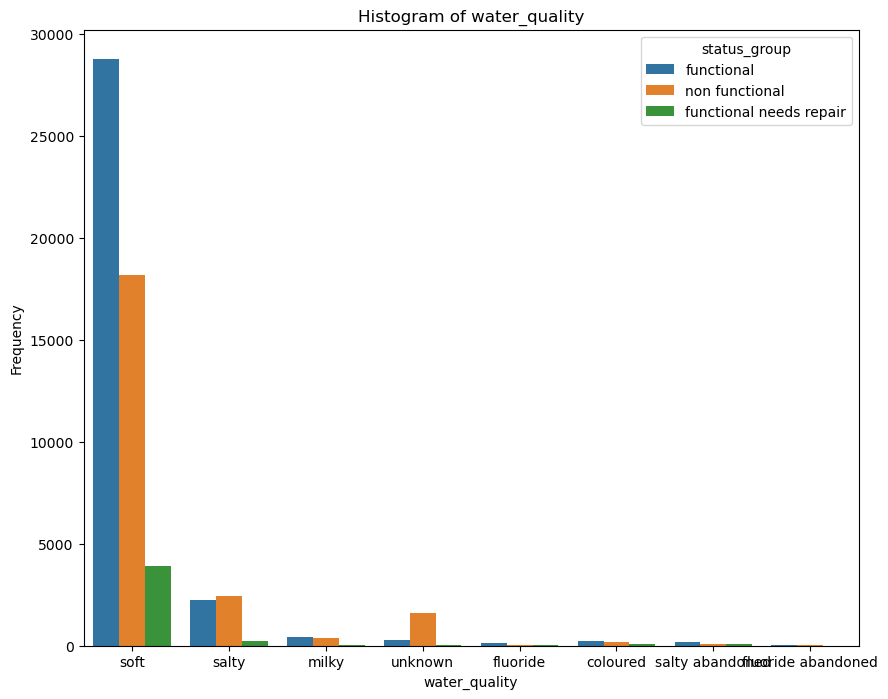

In [311]:
    fig, ax = plt.subplots(figsize=(10, 8))
    fig=sns.countplot(df,x='water_quality',hue='status_group',ax=ax)  
    plt.title(f'Histogram of {"water_quality"}')
    plt.xlabel('water_quality')
    plt.ylabel('Frequency')
    plt.show()

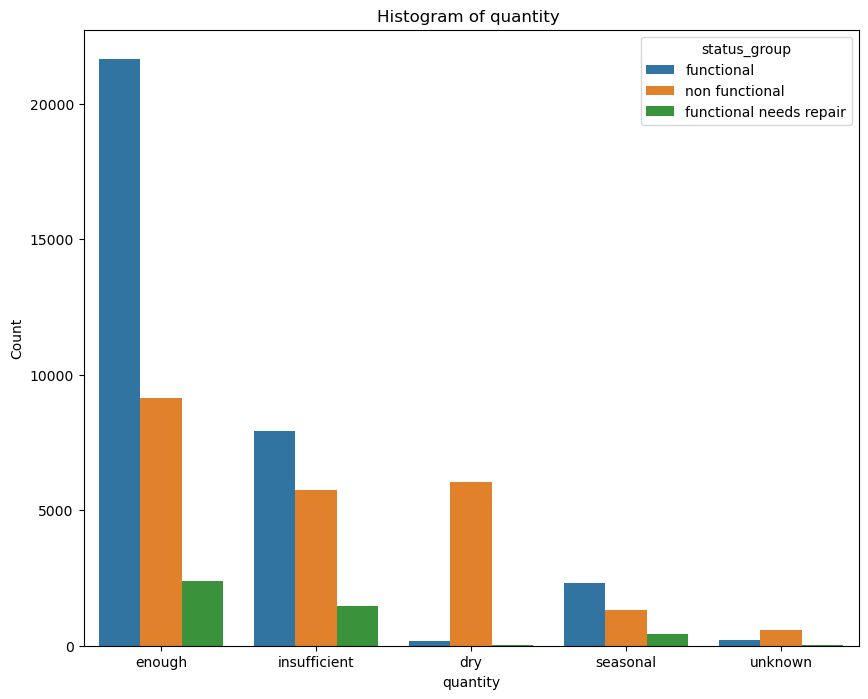

In [312]:
    fig, ax = plt.subplots(figsize=(10, 8))
    fig=sns.countplot(df,x='quantity',hue='status_group',ax=ax)  
    plt.title(f'Histogram of {"quantity "}')
    plt.xlabel('quantity')
    plt.ylabel('Count')
    plt.show()

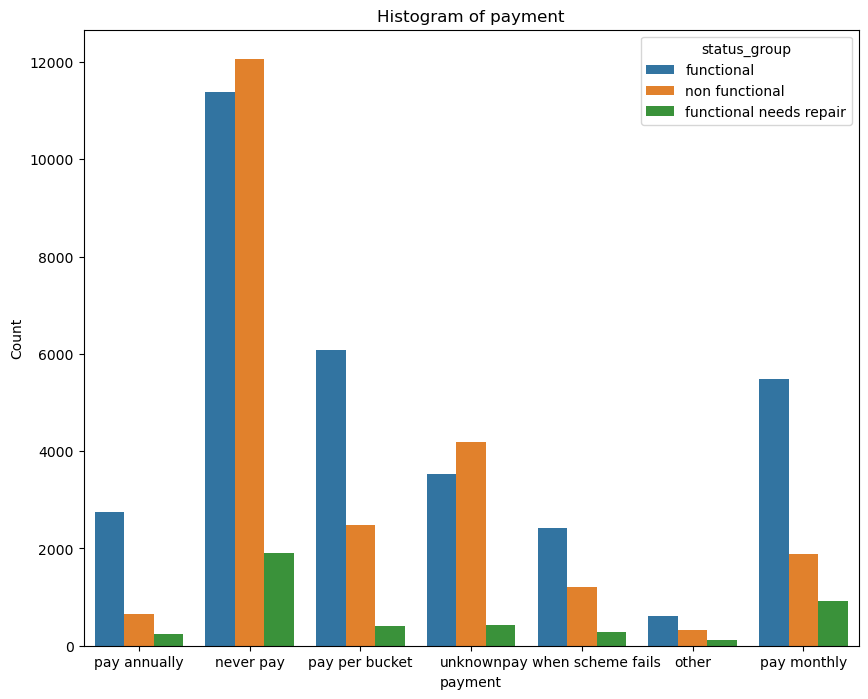

In [313]:
    fig, ax = plt.subplots(figsize=(10, 8))
    fig=sns.countplot(df,x='payment',hue='status_group',ax=ax)  
    plt.title(f'Histogram of {"payment"}')
    plt.xlabel('payment')
    plt.ylabel('Count')
    plt.show()

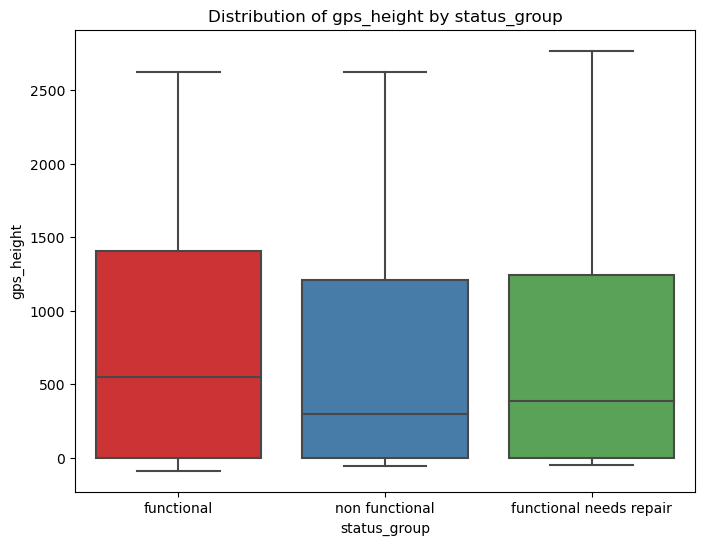

In [314]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='status_group', y='gps_height', palette='Set1')
plt.title('Distribution of gps_height by status_group')
plt.xlabel('status_group')
plt.ylabel('gps_height')
plt.show()

#### there is problem in construction_year

In [240]:
df['construction_year'].unique()

array([1999, 2010, 2009, 1986,    0, 2011, 1987, 1991, 1978, 1992, 2008,
       1974, 2000, 2002, 2004, 1972, 2003, 1980, 2007, 1973, 1985, 1970,
       1995, 2006, 1962, 2005, 1997, 2012, 1996, 1977, 1983, 1984, 1990,
       1982, 1976, 1988, 1989, 1975, 1960, 1961, 1998, 1963, 1971, 1994,
       1968, 1993, 2001, 1979, 1967, 2013, 1969, 1981, 1964, 1966, 1965],
      dtype=int64)

##### Handle construction_year

In [241]:
df[df['construction_year']==0]

,amount_tsh,date_recorded,gps_height,longitude,latitude,num_private,basin,region_code,district_code,population,public_meeting,scheme_management,permit,construction_year,extraction_type,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,source,source_class,waterpoint_type,status_group
4,0.0,2011-07-13,0,31.130847,-1.825359,0,Lake Victoria,18,1,0,True,NaN,True,0,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,rainwater harvesting,surface,communal standpipe,functional
6,0.0,2012-10-01,0,33.362410,-3.766365,0,Internal,17,3,0,True,VWC,True,0,swn 80,handpump,vwc,user-group,never pay,never pay,soft,good,enough,machine dbh,groundwater,hand pump,non functional
7,0.0,2012-10-09,0,32.620617,-4.226198,0,Lake Tanganyika,17,3,0,True,NaN,True,0,nira/tanira,handpump,wug,user-group,unknown,unknown,milky,milky,enough,shallow well,groundwater,hand pump,non functional
8,0.0,2012-11-03,0,32.711100,-5.146712,0,Lake Tanganyika,14,6,0,True,VWC,True,0,india mark ii,handpump,vwc,user-group,never pay,never pay,salty,salty,seasonal,machine dbh,groundwater,hand pump,non functional
9,0.0,2011-08-03,0,30.626991,-1.257051,0,Lake Victoria,18,1,0,True,NaN,True,0,nira/tanira,handpump,vwc,user-group,never pay,never pay,soft,good,enough,shallow well,groundwater,hand pump,functional
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59384,0.0,2011-07-10,0,30.667805,-2.483710,0,Lake Victoria,18,30,0,True,VWC,False,0,gravity,gravity,vwc,user-group,never pay,never pay,soft,good,insufficient,spring,groundwater,communal standpipe,non functional
59392,0.0,2011-04-15,0,33.009440,-8.520888,0,Lake Rukwa,12,1,0,True,VWC,True,0,gravity,gravity,vwc,user-group,never pay,never pay,soft,good,enough,spring,groundwater,communal standpipe,non functional
59393,0.0,2012-10-27,0,33.866852,-4.287410,0,Internal,14,2,0,False,Water authority,False,0,gravity,gravity,private operator,commercial,pay per bucket,per bucket,soft,good,insufficient,dam,surface,other,functional
59397,0.0,2011-04-11,0,34.017087,-8.750434,0,Rufiji,12,7,0,True,VWC,False,0,swn 80,handpump,vwc,user-group,pay monthly,monthly,fluoride,fluoride,enough,machine dbh,groundwater,hand pump,functional


##### Handle date_recorded

In [57]:
df['date_recorded']=pd.to_datetime(df['date_recorded'])

In [58]:
df['Year_recorded']=df['date_recorded'].dt.year


In [59]:
df['construction_year'].replace(0, np.nan, inplace=True) 


In [60]:
df['construction_year'].fillna(df['construction_year'].median(), inplace=True)


In [61]:
df['age'] = df['Year_recorded'] -df['construction_year']


In [62]:
df['age'].value_counts()

 11.0    14695
 12.0     5701
 13.0     4079
 3.0      2740
 1.0      2303
 2.0      2130
 5.0      1980
 4.0      1903
 7.0      1404
 6.0      1381
 8.0      1160
 14.0     1160
 33.0     1120
 15.0      993
 23.0      905
 10.0      868
 16.0      826
 9.0       814
 19.0      766
 27.0      762
 18.0      754
 31.0      709
 28.0      709
 35.0      647
 17.0      636
 39.0      601
 37.0      600
 26.0      589
 0.0       588
 25.0      583
 21.0      578
 29.0      564
 20.0      541
 41.0      488
 30.0      359
 43.0      356
 38.0      351
 36.0      325
 22.0      323
 24.0      261
 40.0      233
 34.0      184
 32.0      174
 53.0       91
 42.0       90
 50.0       84
 45.0       66
 46.0       48
 44.0       47
 48.0       41
 51.0       31
 49.0       25
 47.0       14
 52.0       11
-5.0         3
-4.0         2
-2.0         1
-7.0         1
-1.0         1
-3.0         1
Name: age, dtype: int64

In [63]:
df.drop(df[df['age'] < 0].index, inplace=True)

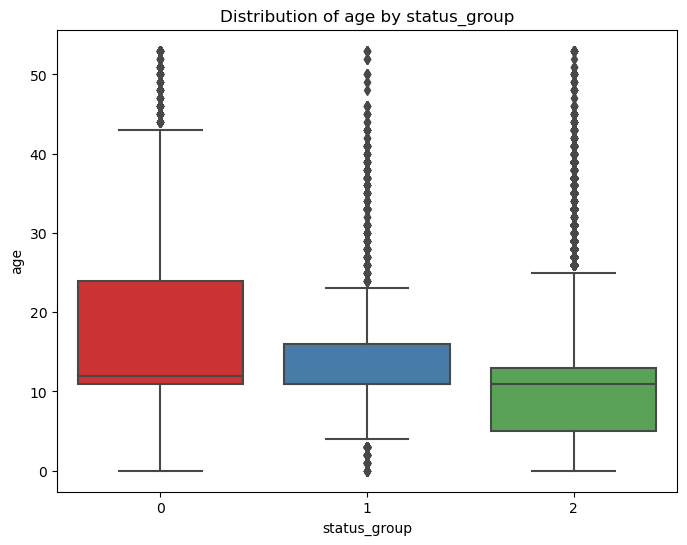

In [90]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='status_group', y='age', palette='Set1')
plt.title('Distribution of age by status_group')
plt.xlabel('status_group')
plt.ylabel('age')
plt.show()

In [64]:
df.drop(['construction_year','date_recorded','Year_recorded'],axis=1,inplace=True)

#### Handle status_group

In [65]:
df['status_group'].value_counts()

functional                 32255
non functional             22819
functional needs repair     4317
Name: status_group, dtype: int64

In [66]:
dic={'functional':2,'functional needs repair':1,'non functional':0}
df['status_group']=df['status_group'].map(dic)

In [67]:
categrical_list=df.select_dtypes(exclude=[np.number]).dtypes.index

In [68]:
categrical_list

Index(['basin', 'region', 'public_meeting', 'scheme_management', 'permit',
       'extraction_type', 'extraction_type_class', 'management',
       'management_group', 'payment', 'payment_type', 'water_quality',
       'quality_group', 'quantity', 'source', 'source_class',
       'waterpoint_type'],
      dtype='object')

In [69]:
numeric_columns=df.select_dtypes(include=[np.number]).dtypes.index

In [70]:
numeric_columns

Index(['amount_tsh', 'gps_height', 'longitude', 'latitude', 'num_private',
       'region_code', 'district_code', 'population', 'status_group', 'age'],
      dtype='object')

In [71]:
corr=df[numeric_columns].corr()

<Axes: >

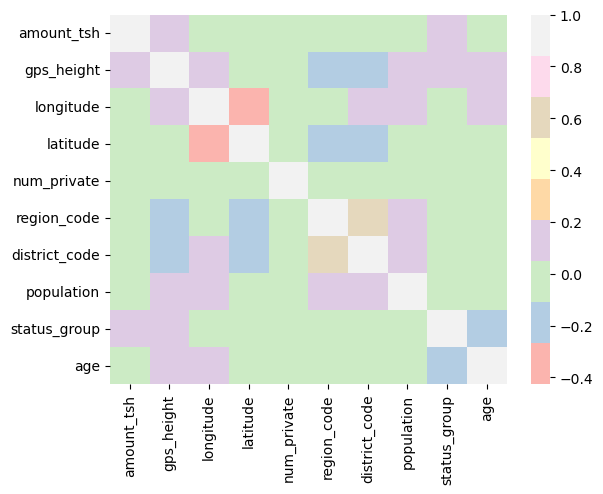

In [257]:
sns.heatmap(corr,cmap='Pastel1')

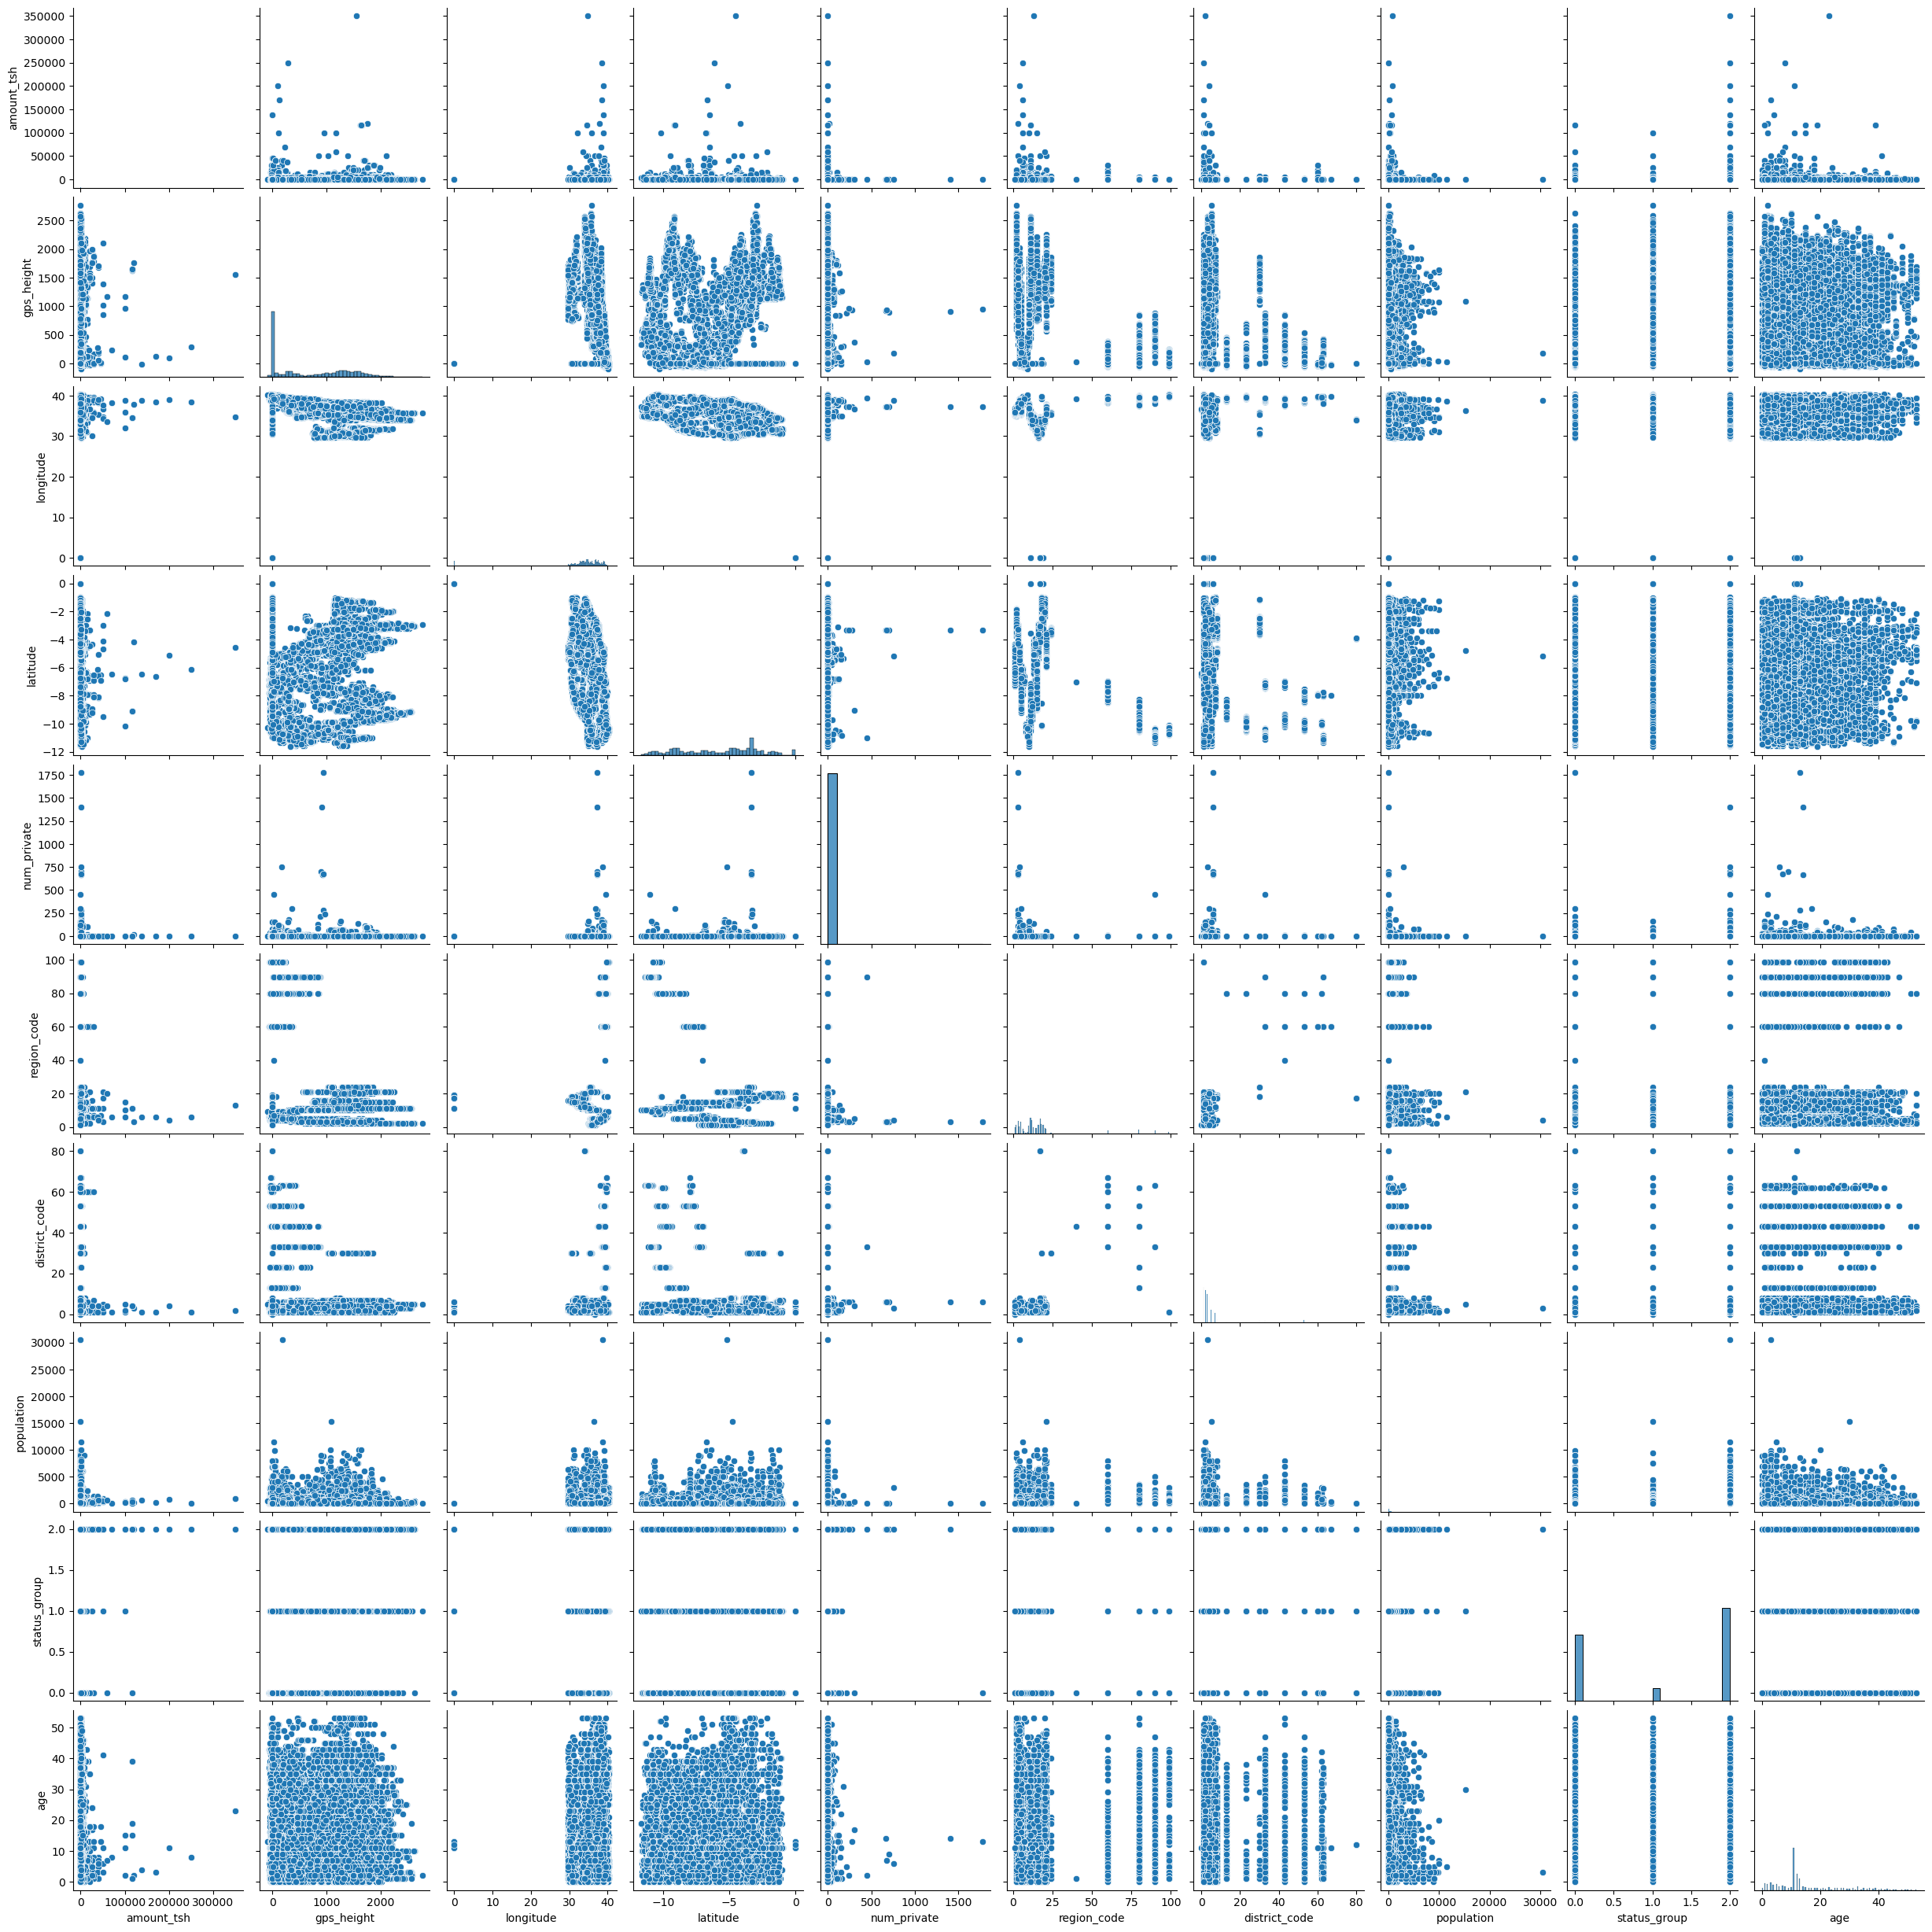

In [258]:
sns.pairplot(df[numeric_columns])

In [72]:
for col in categrical_list:
    print(col,(df[col].value_counts()))
    print('*********************')

basin Lake Victoria              10247
Pangani                     8938
Rufiji                      7973
Internal                    7785
Lake Tanganyika             6431
Wami / Ruvu                 5986
Lake Nyasa                  5085
Ruvuma / Southern Coast     4492
Lake Rukwa                  2454
Name: basin, dtype: int64
*********************
region Iringa           5293
Shinyanga        4982
Mbeya            4639
Kilimanjaro      4379
Morogoro         4006
Arusha           3350
Kagera           3316
Mwanza           3102
Kigoma           2816
Ruvuma           2640
Pwani            2632
Tanga            2545
Dodoma           2201
Singida          2093
Mara             1968
Tabora           1959
Rukwa            1807
Mtwara           1729
Manyara          1583
Lindi            1546
Dar es Salaam     805
Name: region, dtype: int64
*********************
public_meeting True     51003
False     5055
Name: public_meeting, dtype: int64
*********************
scheme_management VWC        

#### Handle null values

In [73]:
for col in df_null_values :
    df.fillna('unknown',inplace=True)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 59391 entries, 0 to 59399
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   amount_tsh             59391 non-null  float64
 1   gps_height             59391 non-null  int64  
 2   longitude              59391 non-null  float64
 3   latitude               59391 non-null  float64
 4   num_private            59391 non-null  int64  
 5   basin                  59391 non-null  object 
 6   region                 59391 non-null  object 
 7   region_code            59391 non-null  int64  
 8   district_code          59391 non-null  int64  
 9   population             59391 non-null  int64  
 10  public_meeting         59391 non-null  object 
 11  scheme_management      59391 non-null  object 
 12  permit                 59391 non-null  object 
 13  extraction_type        59391 non-null  object 
 14  extraction_type_class  59391 non-null  object 
 15  ma

##### Handling Outliers

In [75]:
outliears = detect_outliers(df[numeric_columns[-1:]],0,df[numeric_columns[-1:]].columns)
df[numeric_columns].drop(outliears,inplace=True)

C:\Users\Omar\AppData\Local\Temp\ipykernel_9112\2641384667.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[numeric_columns].drop(outliears,inplace=True)


In [76]:
df.head()

,amount_tsh,gps_height,longitude,latitude,num_private,basin,region,region_code,district_code,population,public_meeting,scheme_management,permit,extraction_type,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,source,source_class,waterpoint_type,status_group,age
0,6000.0,1390,34.938093,-9.856322,0,Lake Nyasa,Iringa,11,5,109,True,VWC,False,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,spring,groundwater,communal standpipe,2,12.0
1,0.0,1399,34.698766,-2.147466,0,Lake Victoria,Mara,20,2,280,unknown,Other,True,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,rainwater harvesting,surface,communal standpipe,2,3.0
2,25.0,686,37.460664,-3.821329,0,Pangani,Manyara,21,4,250,True,VWC,True,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,dam,surface,communal standpipe multiple,2,4.0
3,0.0,263,38.486161,-11.155298,0,Ruvuma / Southern Coast,Mtwara,90,63,58,True,VWC,True,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,machine dbh,groundwater,communal standpipe multiple,0,27.0
4,0.0,0,31.130847,-1.825359,0,Lake Victoria,Kagera,18,1,0,True,unknown,True,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,rainwater harvesting,surface,communal standpipe,2,11.0


In [77]:
x=df.drop('status_group',axis=1)

y=df['status_group']

In [78]:

x_encoded= pd.get_dummies(x)


In [79]:
x_train, x_test, y_train, y_test = train_test_split(x_encoded, y, test_size=0.2, random_state=42)


##### Scaling Data

In [80]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


#### Modeling xgboost

In [81]:
import xgboost as xgb


In [82]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100, 
    max_depth=3,       
    learning_rate=0.1 
)


In [83]:
xgb_model.fit(x_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              objective='multi:softprob', predictor=None, ...)

In [84]:
y_pred=xgb_model.predict(x_test)

acuuracy x_train 0.7491791547398552
acuuracy x_test 0.738866907988888


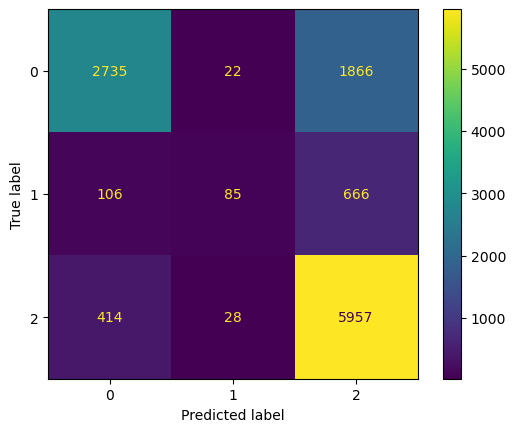

              precision    recall  f1-score   support

           0       0.84      0.59      0.69      4623
           1       0.63      0.10      0.17       857
           2       0.70      0.93      0.80      6399

    accuracy                           0.74     11879
   macro avg       0.72      0.54      0.56     11879
weighted avg       0.75      0.74      0.71     11879



In [85]:
print('acuuracy x_train',accuracy_score(y_train,xgb_model.predict(x_train)))
print('acuuracy x_test',accuracy_score(y_test,xgb_model.predict(x_test)))
cm = confusion_matrix(y_test, y_pred, labels=xgb_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=xgb_model.classes_)
disp.plot()
plt.show()
print(classification_report(y_test,y_pred))

#### Modeling svc

In [87]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=30, 
                             criterion='gini',
                             max_depth=None,
                             min_samples_split=8)
clf.fit(x_train,y_train)
y_train_pred = clf.predict(x_train)
y_test_pred = clf.predict(x_test)
print('classification_report for y_train : \n',classification_report(y_train_pred, y_train))
print('--------------------------------------------------')
print('classification_report for y_test : \n',classification_report(y_test_pred, y_test))
print('----------------------------------------------------------------------------------')

print('acurracy score for y_train : \n',accuracy_score(y_train_pred, y_train))
print('*********************************')
print('acuracy score for y_test : \n',accuracy_score(y_test_pred, y_test))
print('----------------------------------------------------------------------------------')

print('confusion matrix is',(y_test_pred,y_test))

classification_report for y_train : 
               precision    recall  f1-score   support

           0       0.90      0.94      0.92     17366
           1       0.57      0.86      0.69      2316
           2       0.96      0.90      0.93     27830

    accuracy                           0.91     47512
   macro avg       0.81      0.90      0.84     47512
weighted avg       0.92      0.91      0.91     47512

--------------------------------------------------
classification_report for y_test : 
               precision    recall  f1-score   support

           0       0.77      0.84      0.81      4213
           1       0.33      0.56      0.42       500
           2       0.89      0.80      0.84      7166

    accuracy                           0.80     11879
   macro avg       0.66      0.74      0.69     11879
weighted avg       0.83      0.80      0.81     11879

----------------------------------------------------------------------------------
acurracy score for y_train : 

## Gradient boost

In [88]:
from sklearn.ensemble import GradientBoostingClassifier
Grad=GradientBoostingClassifier()
Grad.fit(x_train,y_train)
y_train_pred = Grad.predict(x_train)
y_test_pred = Grad.predict(x_test)
print('classification_report for y_train : \n',classification_report(y_train_pred, y_train))
print('--------------------------------------------------')
print('classification_report for y_test : \n',classification_report(y_test_pred, y_test))
print('----------------------------------------------------------------------------------')

print('acurracy score for y_train : \n',accuracy_score(y_train_pred, y_train))
print('*********************************')
print('acuracy score for y_test : \n',accuracy_score(y_test_pred, y_test))
print('----------------------------------------------------------------------------------')

print('confusion matrix is',(y_test_pred,y_test))

classification_report for y_train : 
               precision    recall  f1-score   support

           0       0.64      0.83      0.72     13939
           1       0.15      0.63      0.24       813
           2       0.92      0.73      0.82     32760

    accuracy                           0.76     47512
   macro avg       0.57      0.73      0.59     47512
weighted avg       0.83      0.76      0.78     47512

--------------------------------------------------
classification_report for y_test : 
               precision    recall  f1-score   support

           0       0.62      0.83      0.71      3449
           1       0.15      0.59      0.24       214
           2       0.92      0.72      0.80      8216

    accuracy                           0.75     11879
   macro avg       0.56      0.71      0.58     11879
weighted avg       0.82      0.75      0.77     11879

----------------------------------------------------------------------------------
acurracy score for y_train : 

##### Ada Boost Classifier

In [89]:
from sklearn.ensemble import AdaBoostClassifier
Ada=AdaBoostClassifier()
Ada.fit(x_train,y_train)
y_train_pred = Ada.predict(x_train)
y_test_pred = Ada.predict(x_test)
print('classification_report for y_train : \n',classification_report(y_train_pred, y_train))
print('--------------------------------------------------')
print('classification_report for y_test : \n',classification_report(y_test_pred, y_test))
print('----------------------------------------------------------------------------------')

print('acurracy score for y_train : \n',accuracy_score(y_train_pred, y_train))
print('*********************************')
print('acuracy score for y_test : \n',accuracy_score(y_test_pred, y_test))
print('----------------------------------------------------------------------------------')

print('confusion matrix is',(y_test_pred,y_test))

classification_report for y_train : 
               precision    recall  f1-score   support

           0       0.61      0.78      0.69     14302
           1       0.09      0.54      0.15       572
           2       0.90      0.71      0.79     32638

    accuracy                           0.73     47512
   macro avg       0.53      0.68      0.54     47512
weighted avg       0.80      0.73      0.75     47512

--------------------------------------------------
classification_report for y_test : 
               precision    recall  f1-score   support

           0       0.59      0.78      0.68      3506
           1       0.08      0.50      0.14       136
           2       0.90      0.70      0.78      8237

    accuracy                           0.72     11879
   macro avg       0.52      0.66      0.53     11879
weighted avg       0.80      0.72      0.75     11879

----------------------------------------------------------------------------------
acurracy score for y_train : 